# Oppgave: Lastflytanalyse med Newton-Raphson

Betrakt kraftnettet vist i figuren nedenfor.

```text
       Bus 1                           Bus 3
         |                               |
         |-------- j0.4 pu --------------|
         |                               |
         |                               |
         +----                       ----+
              \                     /
               \                   /
                \                 /
                 \               /
                  \             /
                   \           /
                    \         /
                     \       /
               =================
                    Bus 2
```


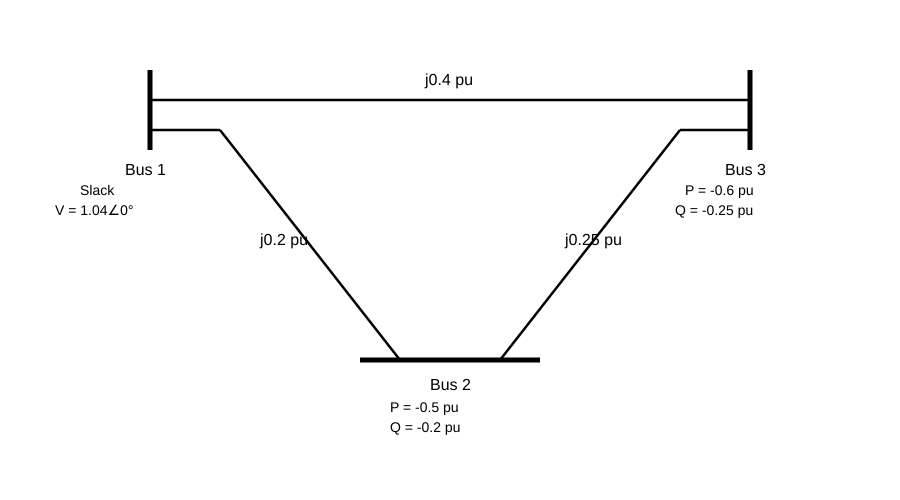

In [1]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """

<svg width="900" height="500" xmlns="http://www.w3.org/2000/svg">

  <style>
    .bus { stroke:black; stroke-width:5; }
    .line { stroke:black; stroke-width:2.5; fill:none; }
    .label { font-family:Arial, sans-serif; font-size:16px; }
    .small { font-family:Arial, sans-serif; font-size:14px; }
  </style>

  <!-- BUS 1 -->
  <line class="bus" x1="150" y1="70" x2="150" y2="150"/>
  <text class="label" x="125" y="175">Bus 1</text>
  <text class="small" x="80" y="195">Slack</text>
  <text class="small" x="55" y="215">V = 1.04∠0°</text>

  <!-- BUS 3 -->
  <line class="bus" x1="750" y1="70" x2="750" y2="150"/>
  <text class="label" x="725" y="175">Bus 3</text>
  <text class="small" x="685" y="195">P = -0.6 pu</text>
  <text class="small" x="675" y="215">Q = -0.25 pu</text>

  <!-- BUS 2 -->
  <line class="bus" x1="360" y1="360" x2="540" y2="360"/>
  <text class="label" x="430" y="390">Bus 2</text>
  <text class="small" x="390" y="412">P = -0.5 pu</text>
  <text class="small" x="390" y="432">Q = -0.2 pu</text>

  <!-- Top branch stubs -->
  <line class="line" x1="150" y1="100" x2="220" y2="100"/>
  <line class="line" x1="680" y1="100" x2="750" y2="100"/>

  <!-- Top branch -->
  <line class="line" x1="220" y1="100" x2="680" y2="100"/>
  <text class="label" x="425" y="85">j0.4 pu</text>

  <!-- Left lower branch -->
  <line class="line" x1="150" y1="130" x2="220" y2="130"/>
  <line class="line" x1="220" y1="130" x2="400" y2="360"/>

  <!-- Right lower branch -->
  <line class="line" x1="680" y1="130" x2="750" y2="130"/>
  <line class="line" x1="500" y1="360" x2="680" y2="130"/>

  <!-- Impedance labels -->
  <text class="label" x="260" y="245">j0.2 pu</text>
  <text class="label" x="565" y="245">j0.25 pu</text>

</svg>
"""

glue("last_flyt", SVG(svg), display=True)


Data er gitt på en base på **100 MVA**.

## Bussdata

### Bus 1 (Slack-buss)

$$
V_1 = 1.04 \angle 0^\circ \text{ pu}
$$

### Bus 2 (PQ-buss)

$$
P_2 = -0.50 \text{ pu}
$$

$$
Q_2 = -0.20 \text{ pu}
$$

### Bus 3 (PQ-buss)

$$
P_3 = -0.60 \text{ pu}
$$

$$
Q_3 = -0.25 \text{ pu}
$$

## Linjedata

| Fra buss | Til buss | Serieimpedans (pu) |
|-----------|-----------|--------------------|
| 1 | 2 | \(j0.2\) |
| 1 | 3 | \(j0.4\) |
| 2 | 3 | \(j0.25\) |

Anta at alle linjer er tapsfrie (\(R=0\)).

## Oppgaver

### a)

Sett opp nettets Y-bus-matrise.

### b)

Klassifiser hver buss som Slack-, PV- eller PQ-buss.

### c)

Anta flat start: $V_2^{(0)} = 1\angle0^\circ$, $ V_3^{(0)} = 1\angle0^\circ$


Beregn de aktive og reaktive effektene ved buss 2 og buss 3.

### d)

Bestem mismatch-vektoren

$$
\Delta=
\begin{bmatrix}
\Delta P_2\\
\Delta P_3\\
\Delta Q_2\\
\Delta Q_3
\end{bmatrix}
$$

for første iterasjon.

### e)

Utled Newton-Raphson-Jacobianen

$$
J=
\begin{bmatrix}
\frac{\partial P}{\partial \delta}
&
\frac{\partial P}{\partial V}
\\
\frac{\partial Q}{\partial \delta}
&
\frac{\partial Q}{\partial V}
\end{bmatrix}
$$

og evaluer den ved flat start.

### f)

Løs ligningssystemet

$$
J\Delta x=\Delta
$$

for korreksjonsvektoren

$$
\Delta x=
\begin{bmatrix}
\Delta\delta_2\\
\Delta\delta_3\\
\Delta V_2\\
\Delta V_3
\end{bmatrix}
$$

### g)

Bestem de oppdaterte spenningsestimatene; $V_2^{(1)}$ og $V_3^{(1)}$ etter første Newton-Raphson-iterasjon.

### h)

Fortsett iterasjonene til maksimal mismatch er mindre enn

$$
10^{-6}
$$

pu.

### i)

Verifiser sluttresultatet ved hjelp av pandapower.

# Løsningsforslag

## a) Sett opp nettets Y-bus-matrise

Gitte impedanser:

$$
Z_{12}=j0.2
$$

$$
Z_{13}=j0.4
$$

$$
Z_{23}=j0.25
$$

Admittansene blir:

$$
Y_{12}=\frac{1}{j0.2}=-j5
$$

$$
Y_{13}=\frac{1}{j0.4}=-j2.5
$$

$$
Y_{23}=\frac{1}{j0.25}=-j4
$$

Y-bus-matrisen er:

$$
Y=
\begin{bmatrix}
-j7.5 & j5 & j2.5\\
j5 & -j9 & j4\\
j2.5 & j4 & -j6.5
\end{bmatrix}
$$

---

## b) Klassifiser bussene

| Buss | Type |
|--------|--------|
| 1 | Slack |
| 2 | PQ |
| 3 | PQ |

---

## c) Beregn effektverdier ved flat start

Startverdier:

$$
V_1=1.04\angle0^\circ
$$

$$
V_2^{(0)}=1.0\angle0^\circ
$$

$$
V_3^{(0)}=1.0\angle0^\circ
$$

Alle spenningsvinkler er null:

$$
\delta_1=\delta_2=\delta_3=0
$$

### Aktiv effekt ved buss 2

$$
P_2
=
V_2
\sum_{n=1}^{3}
V_n
\left[
G_{2n}\cos(\delta_2-\delta_n)
+
B_{2n}\sin(\delta_2-\delta_n)
\right]
$$

Siden

$$
G_{2n}=0
$$

og

$$
\sin(0)=0
$$

får vi

$$
P_2^{calc}=0
$$

### Aktiv effekt ved buss 3

På samme måte:

$$
P_3^{calc}=0
$$

### Reaktiv effekt ved buss 2

$$
Q_2
=
V_2
\sum_{n=1}^{3}
V_n
\left[
G_{2n}\sin(\delta_2-\delta_n)
-
B_{2n}\cos(\delta_2-\delta_n)
\right]
$$

$$
=
1
\left[
1.04(-5)+1(9)+1(-4)
\right]
$$

$$
=
-5.2+9-4
$$

$$
=
-0.20
$$

Dermed:

$$
Q_2^{calc}=-0.20
$$

### Reaktiv effekt ved buss 3

$$
Q_3
=
1
\left[
1.04(-2.5)+1(-4)+1(6.5)
\right]
$$

$$
=
-2.6-4+6.5
$$

$$
=
-0.10
$$

Dermed:

$$
Q_3^{calc}=-0.10
$$

---

## d) Bestem residualvektoren

Spesifiserte effekter:

$$
P_2^{spec}=-0.50
$$

$$
P_3^{spec}=-0.60
$$

$$
Q_2^{spec}=-0.20
$$

$$
Q_3^{spec}=-0.25
$$

Residualene blir:

$$
\Delta P_2
=
P_2^{spec}-P_2^{calc}
=
-0.50-0
=
-0.50
$$

$$
\Delta P_3
=
P_3^{spec}-P_3^{calc}
=
-0.60-0
=
-0.60
$$

$$
\Delta Q_2
=
Q_2^{spec}-Q_2^{calc}
=
-0.20-(-0.20)
=
0
$$

$$
\Delta Q_3
=
Q_3^{spec}-Q_3^{calc}
=
-0.25-(-0.10)
=
-0.15
$$
Residualvektoren blir:

$$
F(x)=
\begin{bmatrix}
-0.50\\
-0.60\\
0\\
-0.15
\end{bmatrix}
$$

---

## e) Jacobian ved flat start

For et tapsfritt nett er

$$
G_{ij}=0
$$

og ved flat start:

$$
N=M=0
$$

Vi får:

$$
H=
\begin{bmatrix}
9 & -4\\
-4 & 6.5
\end{bmatrix}
$$

$$
L=
\begin{bmatrix}
9 & -4\\
-4 & 6.5
\end{bmatrix}
$$

Dermed:

$$
J=
\begin{bmatrix}
9 & -4 & 0 & 0\\
-4 & 6.5 & 0 & 0\\
0 & 0 & 9 & -4\\
0 & 0 & -4 & 6.5
\end{bmatrix}
$$

---



## f) Løs

$$
J\Delta x
=
F(x)
$$

med

$$
\Delta x=
\begin{bmatrix}
\Delta\delta_2\\
\Delta\delta_3\\
\Delta V_2\\
\Delta V_3
\end{bmatrix}
$$

### Vinkelkorreksjoner

Løs

$$
\begin{bmatrix}
9 & -4\\
-4 & 6.5
\end{bmatrix}
\begin{bmatrix}
\Delta\delta_2\\
\Delta\delta_3
\end{bmatrix}
=
\begin{bmatrix}
-0.50\\
-0.60
\end{bmatrix}
$$

gir

$$
\Delta\delta_2
=
-0.146 \text{ rad}
$$

$$
\Delta\delta_3
=
-0.182 \text{ rad}
$$



In [31]:
import numpy as np

H = np.asmatrix('9,-4;-4,6.5')

v = np.array([-0.5, -0.6])

Inv = np.linalg.inv(H)

x = Inv @ v

print(np.round(x,3))

[[-0.133 -0.174]]


### Spenningskorreksjoner

Løs

$$
\begin{bmatrix}
9 & -4\\
-4 & 6.5
\end{bmatrix}
\begin{bmatrix}
\Delta V_2\\
\Delta V_3
\end{bmatrix}
=
\begin{bmatrix}
0\\
-0.15
\end{bmatrix}
$$

gir

$$
\Delta V_2
=
-0.016
$$

$$
\Delta V_3
=
-0.033
$$

---



In [26]:
import numpy as np

L = np.asmatrix('9,-4;-4,6.5')

v = np.array([0, -0.15])

Inv = np.linalg.inv(L)

x = Inv @ v

print(np.round(x,3))

[[-0.014 -0.032]]


## g) Første Newton-Raphson-iterasjon

### Oppdater vinkler

$$
\delta_2^{(1)}
=
0
+
(-0.146)
=
-0.146 \text{ rad}
$$

$$
=
-8.37^\circ
$$

$$
\delta_3^{(1)}
=
0
+
(-0.182)
=
-0.182 \text{ rad}
$$

$$
=
-10.43^\circ
$$

### Oppdater spenninger

$$
V_2^{(1)}
=
1.0-0.016
=
0.984
$$

$$
V_3^{(1)}
=
1.0-0.033
=
0.967
$$

Resultatet etter første iterasjon er:

$$
\boxed{
V_2^{(1)}
=
0.984\angle-8.37^\circ
}
$$

$$
\boxed{
V_3^{(1)}
=
0.967\angle-10.43^\circ
}
$$

---



## h) Konklusjon

Etter første iterasjon er residualene betydelig redusert. Newton-Raphson-prosessen fortsetter med:

1. Beregning av nye effektverdier.
2. Oppbygging av ny residualvektor.
3. Oppbygging av ny Jacobian.
4. Løsning av

$$
J\Delta x=F(x)
$$

5. Oppdatering av spenninger og vinkler.

Prosessen gjentas til residualene er tilstrekkelig små og løsningen har konvergert.

In [7]:
import pandapower as pp

# --------------------------------------------------
# Create network
# --------------------------------------------------

net = pp.create_empty_network(sn_mva=100)

# --------------------------------------------------
# Buses
# --------------------------------------------------

bus1 = pp.create_bus(net, vn_kv=132, name="Bus 1")
bus2 = pp.create_bus(net, vn_kv=132, name="Bus 2")
bus3 = pp.create_bus(net, vn_kv=132, name="Bus 3")

# --------------------------------------------------
# Slack bus
# --------------------------------------------------

pp.create_ext_grid(
    net,
    bus=bus1,
    vm_pu=1.04,
    va_degree=0,
    name="Slack"
)

# --------------------------------------------------
# Lines (modeled as impedances)
# --------------------------------------------------

pp.create_impedance(
    net,
    from_bus=bus1,
    to_bus=bus2,
    rft_pu=0.0,
    xft_pu=0.2,
    rtf_pu=0.0,
    xtf_pu=0.2,
    sn_mva=100,
    name="Z12"
)

pp.create_impedance(
    net,
    from_bus=bus1,
    to_bus=bus3,
    rft_pu=0.0,
    xft_pu=0.4,
    rtf_pu=0.0,
    xtf_pu=0.4,
    sn_mva=100,
    name="Z13"
)

pp.create_impedance(
    net,
    from_bus=bus2,
    to_bus=bus3,
    rft_pu=0.0,
    xft_pu=0.25,
    rtf_pu=0.0,
    xtf_pu=0.25,
    sn_mva=100,
    name="Z23"
)

# --------------------------------------------------
# Loads
# --------------------------------------------------

pp.create_load(
    net,
    bus=bus2,
    p_mw=50,
    q_mvar=20,
    name="Load 2"
)

pp.create_load(
    net,
    bus=bus3,
    p_mw=60,
    q_mvar=25,
    name="Load 3"
)

# --------------------------------------------------
# Run Newton-Raphson load flow
# --------------------------------------------------

pp.runpp(net, algorithm="nr")



# --------------------------------------------------
# Results
# --------------------------------------------------

print("\nBus voltages")
print(net.res_bus[["vm_pu", "va_degree"]])

print("\nBus powers")
print(net.res_bus[["p_mw", "q_mvar"]])

print("\nBranch flows")
print(net.res_impedance[
    ["p_from_mw", "q_from_mvar",
     "p_to_mw", "q_to_mvar"]
])

print("\nConverged:", net.converged)



Bus voltages
      vm_pu  va_degree
0  1.040000   0.000000
1  0.972114  -7.563058
2  0.950950 -10.125586

Bus powers
    p_mw     q_mvar
0 -110.0 -66.702366
1   50.0  20.000000
2   60.0  25.000000

Branch flows
   p_from_mw  q_from_mvar    p_to_mw  q_to_mvar
0  66.532404    39.698457 -66.532404 -28.599107
1  43.467596    27.003909 -43.467596 -17.319578
2  16.532404     8.599107 -16.532404  -7.680422

Converged: True


In [32]:
import numpy as np

B = np.imag(Ybus.toarray())

print(B)

NameError: name 'Ybus' is not defined

# Newton-Raphson Lastflyt med 3-Bussystem

## Nettverk

```text
          X13 = 0.4
     Bus1 -------- Bus3
      | \            |
      |  \           |
      |   \          |
X12=0.2    \         | X23=0.25
      |      \       |
      |       \      |
      |        \     |
     Bus2 ------------
```

## Bussdata

### Slack-buss

\[
V_1 = 1.04\angle 0^\circ
\]

### Last på buss 2

\[
P_2 = -0.50 \; pu
\]

\[
Q_2 = -0.20 \; pu
\]

### Last på buss 3

\[
P_3 = -0.60 \; pu
\]

\[
Q_3 = -0.25 \; pu
\]

Alle effektverdier er gitt på en base på

\[
S_{base}=100\,MVA.
\]

---

# Intuisjonen bak Newton-Raphson

Newton-Raphson prøver å finne spenninger og vinkler som gjør at nettet leverer akkurat den effekten som lastene krever.

Prosedyren er:

1. Gjett spenninger og vinkler.
2. Beregn hva nettet faktisk leverer.
3. Sammenlign med ønsket effekt.
4. Beregn feilen (mismatch).
5. Korriger spenninger og vinkler.
6. Gjenta til feilen er nær null.

---

# Steg 1: Flat Start

Startgjetningen er

\[
V_2=1.0\angle0^\circ
\]

\[
V_3=1.0\angle0^\circ
\]

Dermed:

```text
Bus 1 = 1.04∠0°
Bus 2 = 1.00∠0°
Bus 3 = 1.00∠0°
```

---

# Linjeadmittanser

Linjene er rent reaktive.

## Mellom buss 1 og 2

\[
z_{12}=j0.2
\]

\[
y_{12}=\frac{1}{j0.2}=-j5
\]

## Mellom buss 1 og 3

\[
z_{13}=j0.4
\]

\[
y_{13}=\frac{1}{j0.4}=-j2.5
\]

## Mellom buss 2 og 3

\[
z_{23}=j0.25
\]

\[
y_{23}=\frac{1}{j0.25}=-j4
\]

---

# Y-bus

Dermed blir

\[
Y_{bus}
=
\begin{bmatrix}
-j7.5 & j5 & j2.5\\
j5 & -j9 & j4\\
j2.5 & j4 & -j6.5
\end{bmatrix}
\]

Siden nettet er tapsfritt:

\[
G=0
\]

og

\[
B=
\begin{bmatrix}
-7.5 & 5 & 2.5\\
5 & -9 & 4\\
2.5 & 4 & -6.5
\end{bmatrix}
\]

---

# Beregning av aktiv effekt

Aktiv effekt er

\[
P_k
=
V_k
\sum_{n=1}^{N}
V_n
\left(
G_{kn}\cos(\delta_k-\delta_n)
+
B_{kn}\sin(\delta_k-\delta_n)
\right)
\]

Ved flat start:

\[
\delta_1=\delta_2=\delta_3=0
\]

og

\[
G_{kn}=0
\]

Dermed

\[
\sin(0)=0
\]

slik at

\[
P_2^{calc}=0
\]

\[
P_3^{calc}=0.
\]

---

# Aktiv effekt-mismatch

For buss 2:

\[
\Delta P_2
=
P_2^{spec}-P_2^{calc}
\]

\[
=
-0.50-0
\]

\[
=
-0.50
\]

For buss 3:

\[
\Delta P_3
=
P_3^{spec}-P_3^{calc}
\]

\[
=
-0.60-0
\]

\[
=
-0.60
\]

---

# Beregning av reaktiv effekt

Den generelle formelen er

\[
Q_k
=
V_k
\sum_{n=1}^{N}
V_n
\left(
G_{kn}\sin(\delta_k-\delta_n)
-
B_{kn}\cos(\delta_k-\delta_n)
\right)
\]

Ved flat start:

\[
G_{kn}=0
\]

\[
\cos(0)=1
\]

slik at

\[
Q_k
=
-
V_k
\sum_{n=1}^{N}
V_n B_{kn}
\]

---

# Beregning av Q₂

Fra rad 2 i B-matrisen:

\[
B_{21}=5
\]

\[
B_{22}=-9
\]

\[
B_{23}=4
\]

Setter inn:

\[
Q_2
=
-1
[
1.04(5)
+
1(-9)
+
1(4)
]
\]

\[
=
-(5.2-9+4)
\]

\[
=
-0.20
\]

Dermed

\[
Q_2^{calc}=-0.20
\]

og

\[
\Delta Q_2
=
-0.20-(-0.20)
=
0
\]

---

# Beregning av Q₃

Fra rad 3 i B-matrisen:

\[
B_{31}=2.5
\]

\[
B_{32}=4
\]

\[
B_{33}=-6.5
\]

Setter inn:

\[
Q_3
=
-1
[
1.04(2.5)
+
1(4)
+
1(-6.5)
]
\]

\[
=
-(2.6+4-6.5)
\]

\[
=
-0.10
\]

Dermed

\[
Q_3^{calc}
=
-0.10
\]

---

# Beregning av ΔQ₃

Lasten krever

\[
Q_3^{spec}
=
-0.25
\]

Mens nettet leverer

\[
Q_3^{calc}
=
-0.10
\]

Dermed

\[
\Delta Q_3
=
Q_3^{spec}
-
Q_3^{calc}
\]

\[
=
(-0.25)-(-0.10)
\]

\[
=
-0.15
\]

---

# Mismatch-vektoren

Første iterasjon gir derfor

\[
\Delta P=
\begin{bmatrix}
-0.50\\
-0.60
\end{bmatrix}
\]

\[
\Delta Q=
\begin{bmatrix}
0\\
-0.15
\end{bmatrix}
\]

og samlet:

\[
F=
\begin{bmatrix}
-0.50\\
-0.60\\
0\\
-0.15
\end{bmatrix}
\]

---

# Jacobimatrisen

Newton-Raphson bruker

\[
J=
\begin{bmatrix}
H & N\\
M & L
\end{bmatrix}
\]

hvor

\[
H=
\frac{\partial P}{\partial\delta}
\]

\[
N=
\frac{\partial P}{\partial V}
\]

\[
M=
\frac{\partial Q}{\partial\delta}
\]

\[
L=
\frac{\partial Q}{\partial V}
\]

---

# H-matrisen ved flat start

Når slack-bussen fjernes:

\[
H=
\begin{bmatrix}
9 & -4\\
-4 & 6.5
\end{bmatrix}
\]

---

# Hvor kommer tallene fra?

Fra susceptansmatrisen:

\[
B=
\begin{bmatrix}
-7.5 & 5 & 2.5\\
5 & -9 & 4\\
2.5 & 4 & -6.5
\end{bmatrix}
\]

Off-diagonalene:

\[
H_{23}=-B_{23}=-4
\]

\[
H_{32}=-B_{32}=-4
\]

Diagonalene:

\[
H_{22}=5+4=9
\]

\[
H_{33}=2.5+4=6.5
\]

Dermed

\[
H=
\begin{bmatrix}
9 & -4\\
-4 & 6.5
\end{bmatrix}
\]

---

# Fysisk tolkning

Når vi beregner

\[
P^{calc}
\]

og

\[
Q^{calc}
\]

spør vi egentlig:

> Hvis spenningene akkurat nå er slik vi har gjettet, hvor mye effekt klarer nettet faktisk å levere gjennom linjene og impedansene?

For første gjetning (flat start) leverer nettet:

```text
Bus 2:
P = 0
Q = -0.20

Bus 3:
P = 0
Q = -0.10
```

Mens lastene krever:

```text
Bus 2:
P = -0.50
Q = -0.20

Bus 3:
P = -0.60
Q = -0.25
```

Det oppstår derfor mismatch som Newton-Raphson prøver å eliminere.

Jacobianen brukes til å beregne hvilke endringer i:

- spenningsvinkler \((\delta)\)
- spenningsmagnituder \((V)\)

som må til for at nettet skal levere riktig effekt.

Dermed består Newton-Raphson av:

1. Gjett spenninger.
2. Beregn hva nettet faktisk leverer.
3. Sammenlign med ønsket effekt.
4. Beregn mismatch.
5. Korriger spenningene.
6. Gjenta til mismatch ≈ 0.